In [35]:
import batsim
import galsim
import matplotlib.pyplot as plt

from time import time

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] ='cm'
plt.rcParams['figure.facecolor'] = 'white'
plt.rc('axes', unicode_minus=False)
plt.rc('axes.formatter', use_mathtext=True)

In building BATSim, we have tried to strike a balance between simulation accuracy and speed for a wide range of galaxy morphologies. However, there is no one size-fits-all approach, and as such, BATSim exposes a variety of advanced configuration options for the renderer.

The default values have been optimised on galaxy morphologies taken from the COSMOS sample included with Galsim, for images representative of LSST-like results.

Should you wish to simulate with a very small PSF, high final image resolutions, or very complex galaxy morphologies. You may want to adjust some of these parameters for improved accuracy at the cost of speed.

On the flip side, if you want to generate a sample with lots of big bright galaxies with simple morphologies, you may be able to gain some performance by adjusting these defaults.

First, let's present the full suite of arguments and after we can look at how modifying specific ones may affect our results. The values shown are the defaults.

In [36]:
# Create GSObjects to render
gal = galsim.Sersic(half_light_radius=1.0, n=2.0).shear(e1=0.1, e2=-0.1)
psf = galsim.Moffat(beta=3.5, fwhm=0.7)

# Image params
pix_scale = 0.2
npix=64

# Present full set of arguments for batsim.simulate_galaxy
gal_img = batsim.simulate_galaxy(
    gal_obj=gal, # GSObject of galaxy
    scale=pix_scale, # Final pixel scale
    ngrid=npix, # Final image side length
    transform_obj=None, # BATSim Transform object
    psf_obj=psf, # GSObject of PSF
    draw_method="auto", # turn pixel response on or off
    safety=2.0, # safety factor to scale supersampling. Higher values result in more supersampling
    max_supersample=64, # Maximum supersampling factor. This can be increased for difficult galaxies
    min_supersample=4, # Minimum supersampling factor. We suggest not decreasing this.
    integration_order=2, # Order of Gauss-Legendre quadrature block integration
    max_fine_grid=4096, # Maxmium internal grid-size for rendering supersampled images
    pad=16, # Padding to add before FFT
    precision="single", # Floating point precision to use during simulation
    backend="np", # Backend for math and array ops. Either NumPy or CuPy
    profile=False, # Enable timing and verbose output
    pix_scale=None, # Legacy arguement for scale, retained for conmpatibility
    psf_mode="kvalue", # Sample the PSF directly in k-space (or not)
    force_input_flux=False, # Re-normalise image flux. This should NOT be set to true for magnification
    compensate_integration="quadrature", # Function used to remove smoothing in the Fourier profile
    use_true_center=True, # Match Galsim's centering convention or not
)

Let's start by taking a look at a particularly challenging galaxy. Small galaxies require finer resolution bumping the supersampling needed, and if they are highly ellipticial they also require larger internal stamps to sufficiently contain their extent.

For this we will focus on the arguments directly related to supersampling. To assess how this impacts accuracy, we compute the pixel-to-pixel residuals between BATSim and a GalSim reference and report the peak residual, as well as the total flux in each image.

------------------------------------
Max supersampling factor: 16
GalSim flux: 0.99363410
BATSim flux:    0.97205180
Max abs residual: 1.046e-03
Max abs residual as % of max flux: 3.245%
Simulation took 0.24 seconds
------------------------------------
Max supersampling factor: 32
GalSim flux: 0.99363410
BATSim flux:    0.98499560
Max abs residual: 4.162e-04
Max abs residual as % of max flux: 1.291%
Simulation took 0.75 seconds
------------------------------------
Max supersampling factor: 64
GalSim flux: 0.99363410
BATSim flux:    0.99038339
Max abs residual: 1.541e-04
Max abs residual as % of max flux: 0.478%
Simulation took 1.56 seconds
------------------------------------
Max supersampling factor: 128
GalSim flux: 0.99363410
BATSim flux:    0.99255240
Max abs residual: 5.382e-05
Max abs residual as % of max flux: 0.167%
Simulation took 1.47 seconds


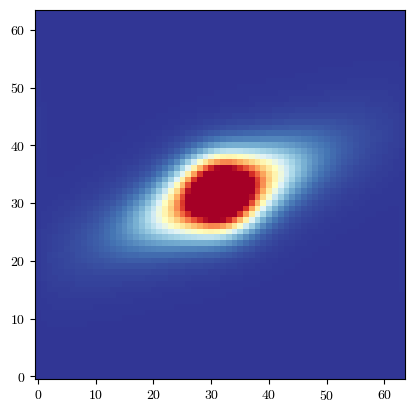

In [37]:
# Small, high-n, highly elliptical.
tricky_gal = galsim.Sersic(half_light_radius=0.15, n=5).shear(e1=0.6, e2=0.6)

# We will loop over different supersampling limits
max_super_vals = [16, 32, 64, 128]

for max_super in max_super_vals:

    print("------------------------------------")
    print("Max supersampling factor:", max_super)

    # Draw with batsim
    start = time()
    batsim_img = batsim.simulate_galaxy(
        gal_obj=tricky_gal,
        scale=pix_scale,
        ngrid=npix,
        transform_obj=None,
        psf_obj=psf,
        draw_method="auto",
        max_supersample=max_super, # Maximum supersampling factor. This can be increased for difficult galaxies
    )
    end = time()

    gal_conv = galsim.Convolve([tricky_gal, psf])
    galsim_img = gal_conv.drawImage(nx=npix, ny=npix, scale=pix_scale).array

    # Look at residuals between images
    residual = galsim_img - batsim_img
    print(f"GalSim flux: {galsim_img.sum():.8f}")
    print(f"BATSim flux:    {batsim_img.sum():.8f}")
    print(f"Max abs residual: {abs(residual).max():.3e}")

    perc_residual = 100 * abs(residual).max() / galsim_img.max()
    print(f"Max abs residual as % of max flux: {perc_residual:.3f}%")
    print(f"Simulation took {end-start:.2f} seconds")

# Plot galaxy
fig = batsim.pltutil.make_plot_image(batsim_img)

Evidently, the agreement between the BATSim and Galsim images improves with increasing supersampling amounts **for this galaxy**. Next we will look at adjusting the maximum internal image size ``max_fine_grid``.

------------------------------------
Max grid size: 1024


GalSim flux: 0.77357638
BATSim flux:    0.77298665
Max abs residual: 2.870e-05
Max abs residual as % of max flux: 0.429%
Simulation took 0.19 seconds
------------------------------------
Max grid size: 2048
GalSim flux: 0.77357638
BATSim flux:    0.77298665
Max abs residual: 2.870e-05
Max abs residual as % of max flux: 0.429%
Simulation took 0.39 seconds
------------------------------------
Max grid size: 4096
GalSim flux: 0.77357638
BATSim flux:    0.77340686
Max abs residual: 8.292e-06
Max abs residual as % of max flux: 0.124%
Simulation took 1.67 seconds
------------------------------------
Max grid size: 8192
GalSim flux: 0.77357638
BATSim flux:    0.77352965
Max abs residual: 2.317e-06
Max abs residual as % of max flux: 0.035%
Simulation took 6.71 seconds


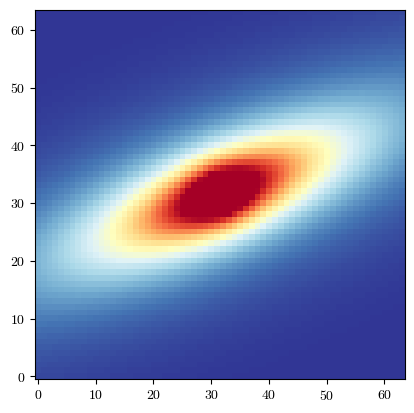

In [38]:
# Large, diffuse, highly elliptical.
tricky_gal = galsim.DeVaucouleurs(half_light_radius=2.0).shear(e1=0.6, e2=0.6)

# We will loop over different supersampling limits
max_grid_vals = [1024, 2048, 4096, 8192]

for max_grid in max_grid_vals:

    print("------------------------------------")
    print("Max grid size:", max_grid)

    # Draw with batsim
    start = time()
    batsim_img = batsim.simulate_galaxy(
        gal_obj=tricky_gal,
        scale=pix_scale,
        ngrid=npix,
        transform_obj=None,
        psf_obj=psf,
        draw_method="auto",
        max_fine_grid=max_grid, # Maximum internal grid size. This can be increased for difficult galaxies
    )
    end = time()

    gal_conv = galsim.Convolve([tricky_gal, psf])
    galsim_img = gal_conv.drawImage(nx=npix, ny=npix, scale=pix_scale).array

    # Look at residuals between images
    residual = galsim_img - batsim_img
    print(f"GalSim flux: {galsim_img.sum():.8f}")
    print(f"BATSim flux:    {batsim_img.sum():.8f}")
    print(f"Max abs residual: {abs(residual).max():.3e}")

    perc_residual = 100 * abs(residual).max() / galsim_img.max()
    print(f"Max abs residual as % of max flux: {perc_residual:.3f}%")
    print(f"Simulation took {end-start:.2f} seconds")

# Plot galaxy
fig = batsim.pltutil.make_plot_image(batsim_img)

``max_fine_grid`` is most relevant to galaxies which require huge internal support images. This can occur when a galaxy's internal rendering resolution is extremely fine and the galaxy is very large and/or highly elliptical. Finally, we will look at the ``integration_order`` arguement, which controls the number of Gauss-Legendre offsets that are used for integrated sampling of each fine pixel to prevent aliasing.

An ``integration_order`` of 1 results in no block integration. For many realistic galaxies, this is impractical due to the huge internal stamps that would be required to prevent alaising during point sampling.

------------------------------------
Integration Order: 1


GalSim flux: 0.99604219
BATSim flux:    5.10848427
Max abs residual: 2.001e-01
Max abs residual as % of max flux: 552.301%
Simulation took 0.89 seconds
------------------------------------
Integration Order: 2
GalSim flux: 0.99604219
BATSim flux:    0.98955822
Max abs residual: 3.130e-04
Max abs residual as % of max flux: 0.864%
Simulation took 1.71 seconds
------------------------------------
Integration Order: 4
GalSim flux: 0.99604219
BATSim flux:    0.99000245
Max abs residual: 2.912e-04
Max abs residual as % of max flux: 0.804%
Simulation took 0.88 seconds


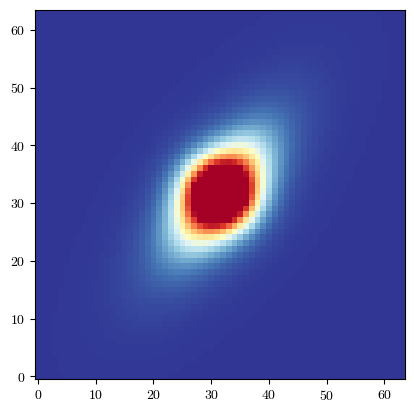

In [39]:
# Small, high-n, highly elliptical.
tricky_gal = galsim.Sersic(half_light_radius=0.1, n=6).shear(e1=-0.2, e2=0.7)

# We will loop over different supersampling limits
int_order_vals = [1, 2, 4]

for int_order in int_order_vals:

    print("------------------------------------")
    print("Integration Order:", int_order)

    # Draw with batsim
    start = time()
    batsim_img = batsim.simulate_galaxy(
        gal_obj=tricky_gal,
        scale=pix_scale,
        ngrid=npix,
        transform_obj=None,
        psf_obj=psf,
        draw_method="auto",
        integration_order=int_order # Integration order for integrated sampling
    )
    end = time()

    gal_conv = galsim.Convolve([tricky_gal, psf])
    galsim_img = gal_conv.drawImage(nx=npix, ny=npix, scale=pix_scale).array

    # Look at residuals between images
    residual = galsim_img - batsim_img
    print(f"GalSim flux: {galsim_img.sum():.8f}")
    print(f"BATSim flux:    {batsim_img.sum():.8f}")
    print(f"Max abs residual: {abs(residual).max():.3e}")

    perc_residual = 100 * abs(residual).max() / galsim_img.max()
    print(f"Max abs residual as % of max flux: {perc_residual:.3f}%")
    print(f"Simulation took {end-start:.2f} seconds")

# Plot galaxy
fig = batsim.pltutil.make_plot_image(batsim_img)

It is clear for this galaxy with no block integration, the resulting aliasing is extreme, leading to a huge flux residual in the final image. After the FFT, we remove the smoothing kernel from the Fourier. This is controlled by ``compensate_integration``, for which we can either choose to use an exact Sinc kernel, the quadrature transfer function, or do no compensation.

Higher integration orders require more sampling evaluations, but, can also reduce the required supersampling more. Currently, integration order is fixed and is not chosen as part of the renderer sampling heuristic, but this is something we plan to incorporate in future.

------------------------------------
Integration compensation function: None


GalSim flux: 0.85708648
BATSim flux:    0.85704029
Max abs residual: 2.856e-06
Max abs residual as % of max flux: 0.032%
Simulation took 1.57 seconds
------------------------------------
Integration compensation function: exact_sinc
GalSim flux: 0.85708648
BATSim flux:    0.85704041
Max abs residual: 2.294e-06
Max abs residual as % of max flux: 0.025%
Simulation took 1.63 seconds
------------------------------------
Integration compensation function: quadrature
GalSim flux: 0.85708648
BATSim flux:    0.85704041
Max abs residual: 2.294e-06
Max abs residual as % of max flux: 0.025%
Simulation took 1.62 seconds


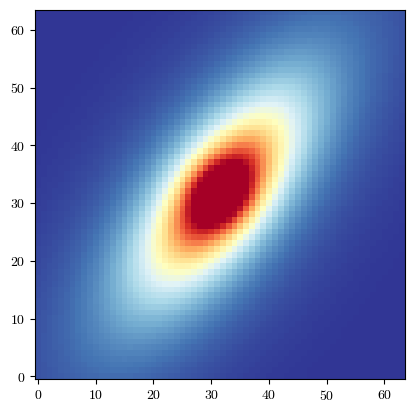

In [40]:
# Small, high-n, highly elliptical.
tricky_gal = galsim.Sersic(half_light_radius=1.5, n=4).shear(e1=-0.2, e2=0.7)

# We will loop over different supersampling limits
compensation_modes = [None, "exact_sinc", "quadrature"]

for mode in compensation_modes:

    print("------------------------------------")
    print("Integration compensation function:", mode)

    # Draw with batsim
    start = time()
    batsim_img = batsim.simulate_galaxy(
        gal_obj=tricky_gal,
        scale=pix_scale,
        ngrid=npix,
        transform_obj=None,
        psf_obj=psf,
        draw_method="auto",
        compensate_integration=mode # Integration order for integrated sampling
    )
    end = time()

    gal_conv = galsim.Convolve([tricky_gal, psf])
    galsim_img = gal_conv.drawImage(nx=npix, ny=npix, scale=pix_scale).array

    # Look at residuals between images
    residual = galsim_img - batsim_img
    print(f"GalSim flux: {galsim_img.sum():.8f}")
    print(f"BATSim flux:    {batsim_img.sum():.8f}")
    print(f"Max abs residual: {abs(residual).max():.3e}")

    perc_residual = 100 * abs(residual).max() / galsim_img.max()
    print(f"Max abs residual as % of max flux: {perc_residual:.3f}%")
    print(f"Simulation took {end-start:.2f} seconds")

# Plot galaxy
fig = batsim.pltutil.make_plot_image(batsim_img)

For most galaxies and for integrations orders greater than 2, ``exact_sinc`` and ``quadrature`` are identical, but we provide the option for both for the sake of felxibility.

At this point, we have covered the most important advacned configuration options, and trying to cover them all would result in a painfully long notebook. Below we include the full renderer with all options listed so you can test different things yourself and see how they affect different galaxies.

GalSim flux: 0.98687613
BATSim flux:    0.98671603
Max abs residual: 6.250e-06
Max abs residual as % of max flux: 0.059%
Simulation took 1.62 seconds


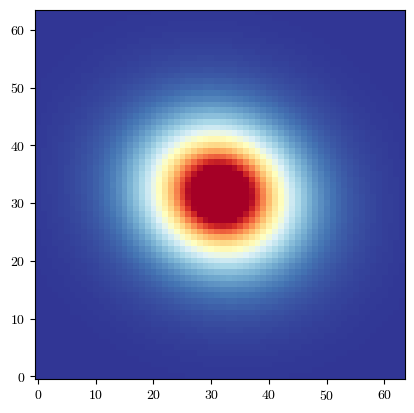

In [43]:
# Create GSObjects to render
gal = galsim.Sersic(half_light_radius=1.0, n=2.0).shear(e1=0.1, e2=-0.1)
psf = galsim.Moffat(beta=3.5, fwhm=0.7)

# Image params
pix_scale = 0.2
npix=64

# Present full set of arguments for batsim.simulate_galaxy
batsim_img = batsim.simulate_galaxy(
    gal_obj=gal, # GSObject of galaxy
    scale=pix_scale, # Final pixel scale
    ngrid=npix, # Final image side length
    transform_obj=None, # BATSim Transform object
    psf_obj=psf, # GSObject of PSF
    draw_method="auto", # turn pixel response on or off
    safety=2.0, # safety factor to scale supersampling. Higher values result in more supersampling
    max_supersample=64, # Maximum supersampling factor. This can be increased for difficult galaxies
    min_supersample=4, # Minimum supersampling factor. We suggest not decreasing this.
    integration_order=2, # Order of Gauss-Legendre quadrature block integration
    max_fine_grid=4096, # Maxmium internal grid-size for rendering supersampled images
    pad=16, # Padding to add before FFT
    precision="single", # Floating point precision to use during simulation
    backend="np", # Backend for math and array ops. Either NumPy or CuPy
    profile=False, # Enable timing and verbose output
    pix_scale=None, # Legacy arguement for scale, retained for conmpatibility
    psf_mode="kvalue", # Sample the PSF directly in k-space (or not)
    force_input_flux=False, # Re-normalise image flux. This should NOT be set to true for magnification
    compensate_integration="quadrature", # Function used to remove smoothing in the Fourier profile
    use_true_center=True, # Match Galsim's centering convention or not
)

gal_conv = galsim.Convolve([gal, psf])
galsim_img = gal_conv.drawImage(nx=npix, ny=npix, scale=pix_scale).array

# Look at residuals between images
residual = galsim_img - batsim_img
print(f"GalSim flux: {galsim_img.sum():.8f}")
print(f"BATSim flux:    {batsim_img.sum():.8f}")
print(f"Max abs residual: {abs(residual).max():.3e}")

perc_residual = 100 * abs(residual).max() / galsim_img.max()
print(f"Max abs residual as % of max flux: {perc_residual:.3f}%")
print(f"Simulation took {end-start:.2f} seconds")

# Plot galaxy
fig = batsim.pltutil.make_plot_image(batsim_img)